# Lab 1 Part A: Uninformed Search for Drone Pathfinding

**Duration:** 1 Week

**Topics Covered:** Problem Formulation, State Spaces, Breadth-First Search (BFS), Depth-First Search (DFS), Evaluation Metrics

---

## Scenario

You are programming the pathfinding logic of an autonomous drone used for environmental monitoring. The drone surveys difficult terrain to detect signs of environmental degradation, such as illegal small-scale mining activities.

The drone must navigate from a designated **start location** to a **goal location** while avoiding obstacles including:

- Dense forests
- Water bodies
- Dangerous pits

To accomplish this task, you will model the environment as a search problem and implement two uninformed search algorithms **Breadth-First Search (BFS)** and **Depth-First Search (DFS)** and compare their performance.

## Learning Objectives

- Formulate a navigation problem using a state-space representation.
- Implement BFS and DFS following a clean problem-oriented interface.
- Evaluate uninformed search algorithms by measuring:
  - Path length (cost)
  - Number of nodes expanded
  - Maximum frontier size
- Understand the trade-offs between BFS and DFS (completeness, optimality, memory usage).

## Setup and Imports


In [18]:
import csv
import requests
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from io import StringIO

# 1. Problem Formulation

Define a class `GridProblem` that encapsulates the drone’s world. The class must provide the following interface:

- `__init__(grid, start, goal)` – stores the 2D grid (`0 = free`, `1 = obstacle`) and start/goal coordinates.
- `initial_state()` – returns the start state.
- `goal_test(state)` – returns `True` if `state` equals the goal.
- `actions(state)` – returns a list of legal neighbour positions (up, down, left, right) that are inside the grid and not obstacles.
- `result(state, action)` – returns the new state after moving in the given direction.
- `step_cost(state, action, next_state)` – returns `1` (uniform cost for now).

**Your task:** Complete the methods marked with `TODO`.

In [9]:
class GridProblem:
    def __init__(self, grid, start, goal):
        """
        grid: 2D list of 0/1 (0=free, 1=obstacle)
        start, goal: tuples (row, col)
        """
        self.grid = grid
        self.rows = len(grid)
        self.cols = len(grid[0])
        self.start = start
        self.goal = goal

    def initial_state(self):
        return self.start

    def goal_test(self, state):
        # TODO: return True if state is the goal
        pass

    def actions(self, state):
        # TODO: return list of valid neighbour positions
        # Directions: up, down, left, right
        # A move is valid if the neighbour is inside the grid and not an obstacle
        pass

    def result(self, state, action):
        # action is a tuple (row, col) of the neighbour
        # Simply return the action (the new state)
        return action

    def step_cost(self, state, action, next_state):
        # TODO: return 1 (each step costs 1)
        pass

## 2. Loading the Map

We’ll load a terrain map from a CSV file where each cell is `0` (free) or `1` (obstacle). The function below reads the CSV and returns a grid, start, and goal.

In [29]:
def load_map_url(url):
    """
    Reads a CSV file from a URL.

    Format:
    - First row: start coordinates as "row,col"
    - Second row: goal coordinates as "row,col"
    - Remaining rows: grid (0 = free, 1 = obstacle)

    Returns:
        grid (list of lists), start (tuple), goal (tuple)
    """
    response = requests.get(url)
    response.raise_for_status()

    f = StringIO(response.text)
    reader = csv.reader(f)
    lines = list(reader)

    start = tuple(map(int, lines[0]))
    goal = tuple(map(int, lines[1]))

    grid = []
    for row in lines[2:]:
        grid.append([int(cell) for cell in row])

    return grid, start, goal

In [30]:
url = "https://raw.githubusercontent.com/danielbyiringiro/intro_to_ai_labs/main/data/example_map.csv"
grid, start, goal = load_map_url(url)


problem = GridProblem(grid, start, goal)

**Visualisation Helper**

In [33]:
def plot_path(grid, start=None, goal=None, path=None):
    """Displays the grid using cell rectangles."""

    arr = np.array(grid)
    height, width = arr.shape

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)  # invert y so row 0 is at top
    ax.set_aspect('equal')
    ax.axis('off')

    cell_border = 0.05  # fraction of a cell

    for i in range(height):
        for j in range(width):
            # Determine fill color using same logic as PIL version
            if arr[i, j] == 1:
                fill = (40/255,  40/255,  40/255)   # wall
            elif start is not None and (i, j) == tuple(start):
                fill = (255/255, 0,       0      )   # start (red)
            elif goal is not None and (i, j) == tuple(goal):
                fill = (0,       171/255, 28/255 )   # goal (green)
            elif path is not None and (i, j) in set(map(tuple, path)):
                fill = (220/255, 235/255, 113/255)   # solution (yellow-green)
            else:
                fill = (237/255, 240/255, 252/255)   # empty (light blue)

            rect = patches.Rectangle(
                (j + cell_border, i + cell_border),          # (x, y) bottom-left
                1 - 2 * cell_border,                          # width
                1 - 2 * cell_border,                          # height
                linewidth=0,
                facecolor=fill
            )
            ax.add_patch(rect)

    # Overlay path line + markers on cell centers
    if path:
        ys, xs = zip(*path)
        # offset by 0.5 to hit cell centers
        ax.plot([x + 0.5 for x in xs], [y + 0.5 for y in ys],
                color='red', linewidth=2, marker='o', markersize=4, zorder=5)

    if start is not None:
        ax.plot(start[1] + 0.5, start[0] + 0.5, 'go', markersize=10, label="Start", zorder=6)

    if goal is not None:
        ax.plot(goal[1] + 0.5, goal[0] + 0.5, 'bo', markersize=10, label="Goal", zorder=6)

    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

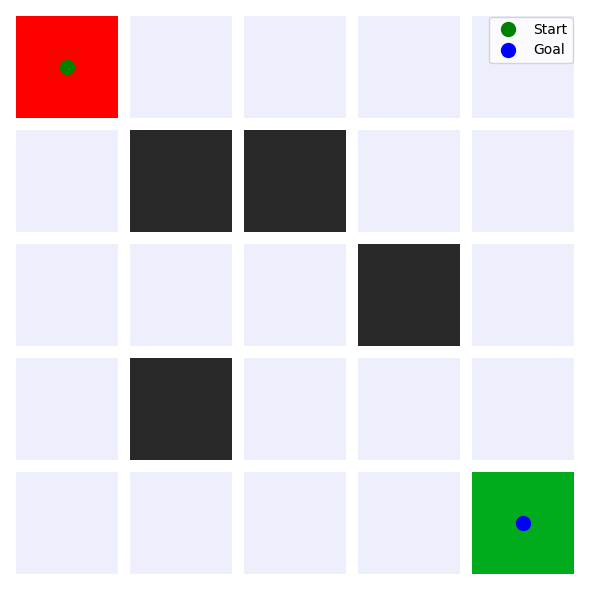

In [35]:
plot_path(grid, start, goal)

## 3. Search Algorithms

You will implement two classic uninformed search algorithms. Both algorithms should:

- Take a `GridProblem` instance.
- Return a tuple: `(solution_path, nodes_expanded, max_frontier_size)`
  - `solution_path` is a list of states from start to goal (inclusive), or `None` if no path exists.
  - `nodes_expanded` counts how many states were removed from the frontier for expansion.
  - `max_frontier_size` is the maximum number of states held in the frontier at any time.

We will use a **graph search** approach with an explored set to avoid revisiting states.


###3.1 Breadth‑First Search (BFS)
Use a FIFO queue (`deque`).

In [37]:
def bfs(problem):
    """Breadth-First Search"""
    # TODO: implement BFS
    # Initialize frontier with start state (or a node containing state + parent)
    # Use a dictionary to track parent pointers: parent[state] = (parent_state, action)
    # explored = set()
    # nodes_expanded = 0
    # max_frontier = 0
    # while frontier not empty:
    #     pop state, increment nodes_expanded
    #     if goal_test: reconstruct path and return
    #     add to explored
    #     for each action in problem.actions(state):
    #         child = problem.result(state, action)
    #         if child not in explored and not in frontier:
    #             record parent, push to frontier
    # update max_frontier
    # return (None, nodes_expanded, max_frontier) if no solution
    pass

  # Hint: Use a deque and popleft() for true FIFO behaviour.

### 3.2 Depth‑First Search (DFS)
Use a LIFO stack (Python `list` with `pop()`). Be careful to manage the frontier correctly.


In [38]:
def dfs(problem):
    """Depth-First Search"""
    # TODO: implement DFS (graph search, same structure as BFS but with stack)
    pass

## 4. Evaluation

###4.1 Run on the Example Map

In [ ]:
path_bfs, expanded_bfs, maxf_bfs = bfs(problem)
path_dfs, expanded_dfs, maxf_dfs = dfs(problem)

print("BFS:")
print("  Path length:", len(path_bfs)-1 if path_bfs else "None")
print("  Nodes expanded:", expanded_bfs)
print("  Max frontier size:", maxf_bfs)

print("\nDFS:")
print("  Path length:", len(path_dfs)-1 if path_dfs else "None")
print("  Nodes expanded:", expanded_dfs)
print("  Max frontier size:", maxf_dfs)

In [ ]:
plot_path(grid, start, goal, path_bfs)
plot_path(grid, start, goal, path_dfs)

###4.2 Questions


1. Optimality: Which algorithm always returns the shortest path? Explain why using the properties of the search strategy and the uniform step cost.

2. Memory: Compare the maximum frontier sizes of BFS and DFS. Under what conditions might DFS use significantly less memory? Under what conditions could it be worse?

3. Completeness: Is DFS complete for this grid problem? Why?

4. Impact of Obstacles: Create a second map with a long narrow corridor and dead ends (e.g., a maze). Measure nodes expanded and frontier size. Which algorithm performs better in terms of expanded nodes? Why?

5. Real‑world Connection: The drone may need to avoid areas that are not completely blocked but have a higher “cost” (e.g., rough terrain that drains the battery faster). Can BFS/DFS handle such varying costs? What would you need to change?

**NB:** For question 4 implement the map in this notebook, answers without code results to back them up will be heavily penalised.

###4.3 Your Own Map
Create at least two additional maps of different sizes and obstacle densities. Tabulate the results (path length, nodes expanded, max frontier) for both algorithms and write a short paragraph interpreting the data.

##5. Submission
Complete the notebook with all functions filled in.

Include the results and answers to the questions.

Save your notebook file as `FirstName_LastName_Lab_1A.ipynb`

Upload the .ipynb file to canvas.